<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 1.
# Стационарность: определение, примеры, диагностика

Главная мысль: **стационарность — это свойство порождающего механизма, а не
картинки.** Ряд может выглядеть «дёргано» и быть стационарным, а может
выглядеть гладко и не быть. Поэтому глаз нужно натренировать на примерах,
где ответ известен заранее, — этим мы и займёмся в разделе 2.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Зачем вообще нужна стационарность: что она даёт прогнозу |
| 1 | Строгая и слабая стационарность; 4 практических пункта проверки |
| 2 | Зоопарк процессов: 7 рядов, для каждого — вердикт и причина |
| 3 | Диагностика по сводным статистикам: `chunk_stats` |
| 4 | Диагностика по ACF: правило «медленное затухание ⇒ нужна разность» |
| 5 | `tsdisplay` — сквозной инструмент на весь семинар |
| 6 | Portmanteau-тесты: Ljung-Box, Box-Pierce |


In [56]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.stats import norm

import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

print("statsmodels:", sm.__version__)

statsmodels: 0.14.6


---
# 0. Зачем нужна стационарность

Сформулируем мотивацию до всяких определений, потому что иначе
стационарность выглядит как формальность, придуманная математиками.

Возьмём два ряда, которые устроены почти одинаково — оба «шагают» вперёд
случайными шагами, различаясь единственным коэффициентом:

$$
\begin{aligned}
\text{(A)} \quad & y_t = 0.7\, y_{t-1} + \varepsilon_t \\
\text{(B)} \quad & y_t = 1.0\, y_{t-1} + \varepsilon_t
\end{aligned}
$$

Первый стационарен, второй — нет (почему именно так, разберём отдельно). Посмотрим, во что это различие
превращается, когда мы пытаемся заглянуть в будущее.

Симулируем из каждого процесса по 300 возможных будущих траекторий,
стартующих из одной и той же точки $y_T = 4$.

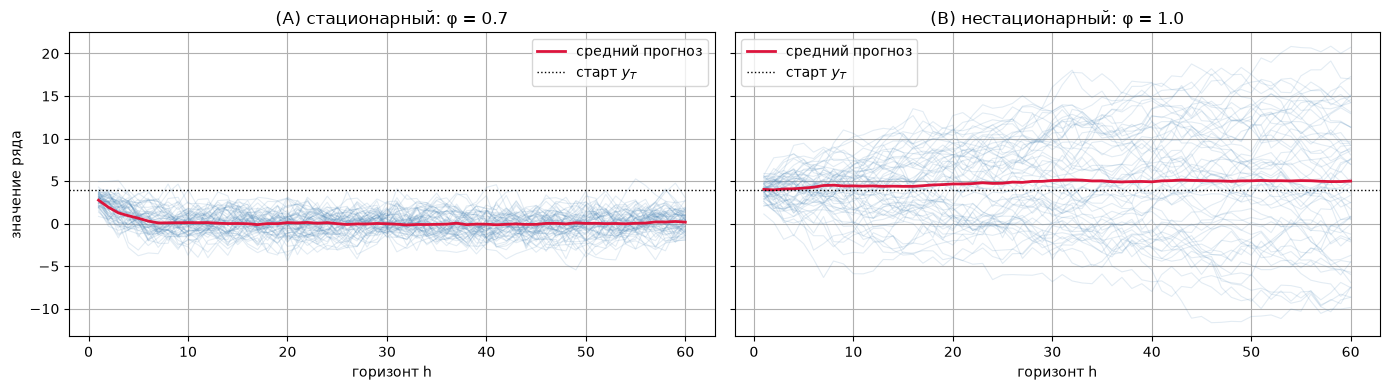

In [57]:
rng = np.random.default_rng(42)

h = 60  # горизонт прогноза
n_paths = 300  # сколько возможных будущих рисуем
y_start = 4.0

futures = {}
for name, phi in [("(A) стационарный: φ = 0.7", 0.7), ("(B) нестационарный: φ = 1.0", 1.0)]:
    paths = np.empty((n_paths, h))
    prev = np.full(n_paths, y_start)
    for step in range(h):
        prev = phi * prev + rng.normal(0, 1, n_paths)
        paths[:, step] = prev
    futures[name] = paths

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (name, paths) in zip(axes, futures.items()):
    ax.plot(np.arange(1, h + 1), paths[:60].T, color="steelblue", alpha=0.15, lw=0.8)
    ax.plot(np.arange(1, h + 1), paths.mean(axis=0), color="crimson", lw=2, label="средний прогноз")
    ax.axhline(y_start, color="black", ls=":", lw=1, label="старт $y_T$")
    ax.set_title(name)
    ax.set_xlabel("горизонт h")
    ax.legend()
axes[0].set_ylabel("значение ряда")
plt.tight_layout()
plt.show()

Разница видна сразу.

* **Слева** веер траекторий быстро «садится» на уровень 0 и дальше не
  расширяется: у процесса есть точка притяжения (своё среднее), и
  отклонения от неё затухают. Средний прогноз (красная линия) сходится к
  этому уровню за ~10 шагов, а разброс вокруг него перестаёт расти.
* **Справа** веер расходится веером до самого края и не имеет никакого
  притягивающего уровня. Средний прогноз навсегда остаётся равным
  стартовому значению — модель буквально говорит «будет как сейчас», —
  но неопределённость вокруг него растёт неограниченно.

Посмотрим на это численно: как ведёт себя разброс будущих значений с
ростом горизонта.

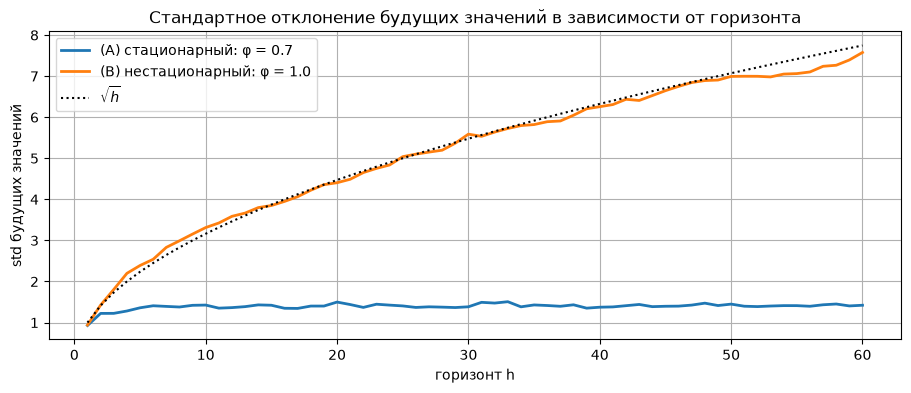

,(A) стационарный: φ = 0.7,(B) нестационарный: φ = 1.0
горизонт h,,
1,0.93,0.94
5,1.36,2.39
20,1.50,4.41
60,1.42,7.58


In [58]:
spread = pd.DataFrame(
    {name: paths.std(axis=0) for name, paths in futures.items()},
    index=pd.RangeIndex(1, h + 1, name="горизонт h"),
)

plt.figure(figsize=(11, 4))
for name in spread.columns:
    plt.plot(spread.index, spread[name], lw=2, label=name)
plt.plot(spread.index, np.sqrt(spread.index), "k:", lw=1.5, label=r"$\sqrt{h}$")
plt.title("Стандартное отклонение будущих значений в зависимости от горизонта")
plt.xlabel("горизонт h")
plt.ylabel("std будущих значений")
plt.legend()
plt.show()

spread.iloc[[0, 4, 19, 59]].round(2)

Для стационарного ряда разброс выходит на плато (для AR(1) — на
$\sigma/\sqrt{1-\varphi^2} \approx 1.4$) уже к 10-му шагу и дальше не
растёт. Для нестационарного он растёт как $\sqrt{h}$ и никогда не
останавливается.

> 🔑 **Прогноз стационарного ряда — это прогноз «к среднему» с
> ограниченной неопределённостью. Прогноз нестационарного ряда — «куда
> угодно»: точечный прогноз не сходится ни к чему осмысленному, а
> интервал расширяется неограниченно.**

Отсюда практический вывод, ради которого всё затевается. Почти все модели,
которые мы будем изучать (AR, MA, ARMA), устроены для стационарного ряда.
Если ряд нестационарен, его сначала **приводят** к стационарности — и чаще
всего это делается взятием разностей $\Delta y_t = y_t - y_{t-1}$.

🔍 Забегая вперёд: буква `d` в названии **ARIMA(p, d, q)** — это ровно
«сколько раз мы взяли разность, чтобы получить стационарный ряд».
Средняя буква аббревиатуры существует исключительно ради сегодняшней
темы. Всё, чем мы займёмся на этой неделе, — это грамотный выбор `d` и модель для того, что осталось после разностей
(семинар 2).

---
# 1. Строгая и слабая стационарность

Интуиция одной фразой: **временной ряд стационарен, если в порождающей его
системе ничего не меняется со временем.** Наблюдения меняются, а правила,
по которым они выпадают, — нет. Теперь два формальных уточнения этой фразы.

## 1.1. Строгая стационарность

Случайный процесс $\{y(t): t \in \mathcal{T}\}$ называется **строго
стационарным**, если для любых моментов $t_1, \dots, t_n \in \mathcal{T}$ и
любого сдвига $h$ (такого, что $t_i + h \in \mathcal{T}$) выполнено

$$\big(y(t_1), y(t_2), \dots, y(t_n)\big) \stackrel{\text{D}}{=}
  \big(y(t_1+h), y(t_2+h), \dots, y(t_n+h)\big),$$

где $\stackrel{\text{D}}{=}$ означает равенство **распределений**.

Проще говоря: совместное распределение любого набора наблюдений не зависит
от того, в какой момент времени мы этот набор взяли. Сдвиг «окна
наблюдения» вправо или влево ничего не меняет.

🔍 Это очень сильное требование, и проверить его на конечной выборке
практически невозможно: у нас **одна** реализация процесса, а речь идёт о
равенстве многомерных распределений. Поэтому на практике проверяют более
слабое свойство.

## 1.2. Слабая стационарность

Процесс $y(t)$ называется **слабо стационарным** (стационарным второго
порядка), если:

1. среднее постоянно во времени: $\mathbb{E}[y(t)] = \mu$ для всех $t$;
2. дисперсия конечна: $\mathbb{E}[y(t)^2] < \infty$ (и, как следствие
   условия 3 при $h=0$, постоянна);
3. ковариация зависит только от расстояния между моментами, но не от их
   положения на оси времени:
   $$\mathrm{cov}\big(y(t),\, y(t+h)\big) = \gamma_h \quad \text{для всех } t.$$

Дальше мы работаем только с процессами в дискретном времени, то есть с
последовательностью случайных величин $y_1, y_2, \dots, y_n$.

## 1.3. Что реально проверяют на практике

Из определения слабой стационарности получается рабочий чек-лист из
четырёх пунктов. К нему мы будем возвращаться в каждом примере раздела 2.

| № | Что проверяем | Как это выглядит при нарушении |
|---|---|---|
| 1 | **Постоянство среднего** — нет тренда | ряд «уползает» вверх или вниз |
| 2 | **Постоянство дисперсии** — нет гетероскедастичности | амплитуда колебаний растёт или падает |
| 3 | **Постоянство автокорреляционной структуры** | связь соседних точек меняется по ходу ряда |
| 4 | **Отсутствие периодической составляющей** — но осторожно! | видимая сезонность фиксированного периода |

🔍 Четвёртый пункт сформулирован нарочито неаккуратно, и в разделе 2.5 мы
увидим контрпример: **бывают периодические ряды, которые слабо
стационарны.** Правильная формулировка — «нет сезонности с *фиксированным
известным* периодом, порождающей зависимость среднего от времени».
Различие тонкое, поэтому его стоит увидеть на примере, а не заучивать.

---
# 2. Зоопарк процессов

Семь рядов подряд. Для каждого — картинка, вердикт и, главное, **причина**
в терминах чек-листа из раздела 1.3. Всё это симуляции: мы точно знаем
правильный ответ, поэтому можем тренировать глаз без риска.

## 2.1. Белый шум — эталон стационарности

**Белый шум** — простейший стационарный процесс и «нулевая точка отсчёта»
для всего курса:

$$\mathbb{E}[y_t] = 0, \qquad \mathrm{Var}[y_t] = \sigma^2,
  \qquad \mathrm{cov}(y_t, y_{t-k}) = 0 \;\; \forall\, k \neq 0.$$

Никакой памяти: значение в момент $t$ не несёт информации о значении в
момент $t+1$. Самый простой представитель — последовательность
независимых одинаково распределённых $\mathcal{N}(0, 1)$.

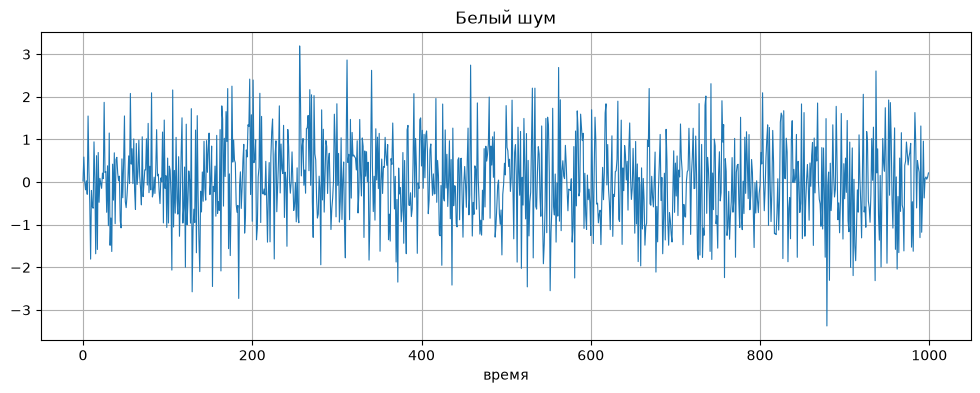

In [59]:
n_obs = 1000
white_noise = pd.Series(rng.normal(size=n_obs))

white_noise.plot(title="Белый шум", xlabel="время", lw=0.8)
plt.show()

Проверим чек-лист по пунктам. Начнём со среднего: посчитаем выборочное
среднее и p-value гипотезы $H_0: \mu = 0$.

In [60]:
mu_hat = white_noise.mean()
z_stat = mu_hat * np.sqrt(n_obs) / white_noise.std()
p_value = 2 * norm.cdf(-abs(z_stat))

print(f"выборочное среднее: {mu_hat:.4f}")
print(f"z-статистика:       {z_stat:.4f}")
print(f"p-value (H0: μ = 0): {p_value:.4f}")

выборочное среднее: 0.0144
z-статистика:       0.4551
p-value (H0: μ = 0): 0.6491


Теперь дисперсия — сравним её на левой и правой части ряда. Если процесс
стационарен, обе оценки должны быть близки.

In [61]:
print(f"std первых 300 наблюдений:   {white_noise.head(300).std():.4f}")
print(f"std последних 300 наблюдений: {white_noise.tail(300).std():.4f}")

std первых 300 наблюдений:   0.9827
std последних 300 наблюдений: 1.0296


Осталась автокорреляционная структура. Её показывает **ACF**
(autocorrelation function) — график выборочных корреляций
$\mathrm{corr}(y_t, y_{t-k})$ по лагам $k$. Для белого шума все они должны
быть нулевыми.

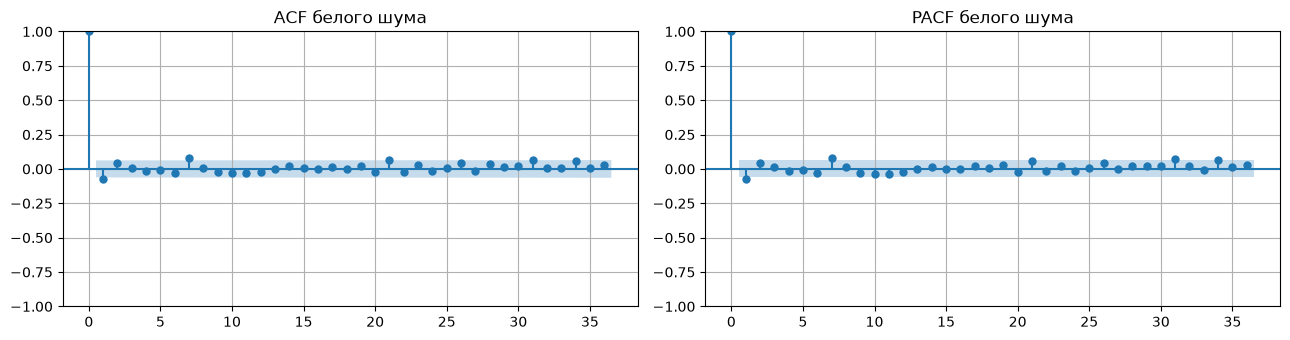

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(white_noise, lags=36, ax=axes[0], title="ACF белого шума")
plot_pacf(white_noise, lags=36, ax=axes[1], method="ywm", title="PACF белого шума")
plt.tight_layout()
plt.show()

Синяя полоса — доверительная зона $\pm 1.96/\sqrt{n}$ вокруг нуля.
Практически все столбики лежат внутри неё: значимых автокорреляций нет.

Но посчитаем, сколько именно столбиков всё-таки вылезло за границу.

In [63]:
acf_wn = acf(white_noise, nlags=36)[1:]
band = 1.96 / np.sqrt(n_obs)
outside = np.flatnonzero(np.abs(acf_wn) > band) + 1

print(f"граница значимости ±{band:.4f}")
print(f"лагов за границей: {len(outside)} из 36 — {list(outside)}")
print(f"ожидаемое число ложных срабатываний при уровне 5%: {0.05 * 36:.1f}")

граница значимости ±0.0620
лагов за границей: 4 из 36 — [np.int64(1), np.int64(7), np.int64(21), np.int64(31)]
ожидаемое число ложных срабатываний при уровне 5%: 1.8


🔍 Полоса построена для **каждого лага по отдельности** на уровне 5%.
Если проверить 36 лагов, то в среднем $0.05 \times 36 \approx 2$ столбика
случайно вылезут за границу даже у идеального белого шума — примерно это
мы и видим. Одиночный выход за полосу на каком-нибудь лаге 21 — это не
находка, а шум множественных сравнений: столбики разбросаны по лагам без
всякой системы, а не сгруппированы в начале или на кратных периоду
позициях. Именно поэтому в разделе 7 мы возьмём тест, который проверяет
**все лаги сразу** и даёт одно p-value вместо тридцати шести.

**Вердикт: стационарен.** Все четыре пункта чек-листа выполнены по
построению.

## 2.2. Случайное блуждание — главный нестационарный ряд

**Случайное блуждание** (random walk) — самый важный нестационарный ряд,
и почти всё содержание этой недели так или иначе про него:

$$y_t = y_{t-1} + \varepsilon_t,$$

где $\varepsilon_t$ — независимые *инновации*, например
$\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$. Каждое новое значение —
это предыдущее плюс случайный шаг.

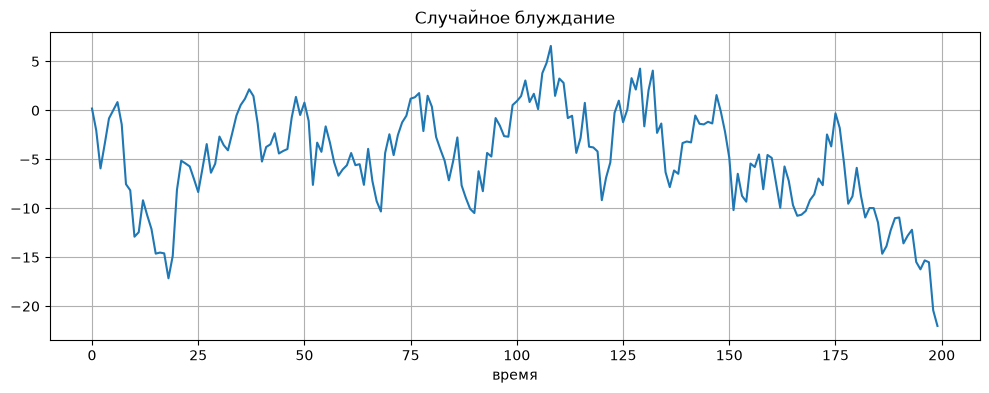

In [64]:
n_rw = 200
sigma_rw = 2.5

rand_walk = pd.Series(np.cumsum(rng.normal(0, sigma_rw, n_rw)))

rand_walk.plot(title="Случайное блуждание", xlabel="время")
plt.show()

🔍 Запустите ячейку несколько раз (при другом `rng`) — вы получите
совершенно непохожие картинки: то растущий «тренд», то падающий, то
горб. Это ключевое свойство: **у случайного блуждания нет тренда**, хотя
любая отдельная реализация выглядит трендовой. Тренд, который вы видите,
— иллюзия, порождённая накоплением независимых шагов.

Почему ряд нестационарен? Есть две связанные причины.

**Зависимость от начального значения.** Раскроем рекурсию:

$$y_t = y_0 + \varepsilon_1 + \varepsilon_2 + \dots + \varepsilon_t.$$

Значение в любой момент зависит от старта и от **всей** суммы прошлых
инноваций. Ни один шок не забывается: он входит в сумму с коэффициентом 1
навсегда.

**Растущая дисперсия.** Из того же разложения, пользуясь независимостью
$\varepsilon_i$:

$$\mathrm{Var}(y_1) = \sigma^2, \qquad
  \mathrm{Var}(y_2) = \mathrm{Var}(\varepsilon_1 + \varepsilon_2) = 2\sigma^2,
  \qquad \dots \qquad
  \boxed{\mathrm{Var}(y_t) = t\,\sigma^2}$$

Дисперсия растёт **линейно по времени** — это прямое нарушение пункта 2
чек-листа. Проверим формулу численно: сгенерируем 2000 независимых
блужданий и посчитаем разброс по ансамблю в каждый момент времени.

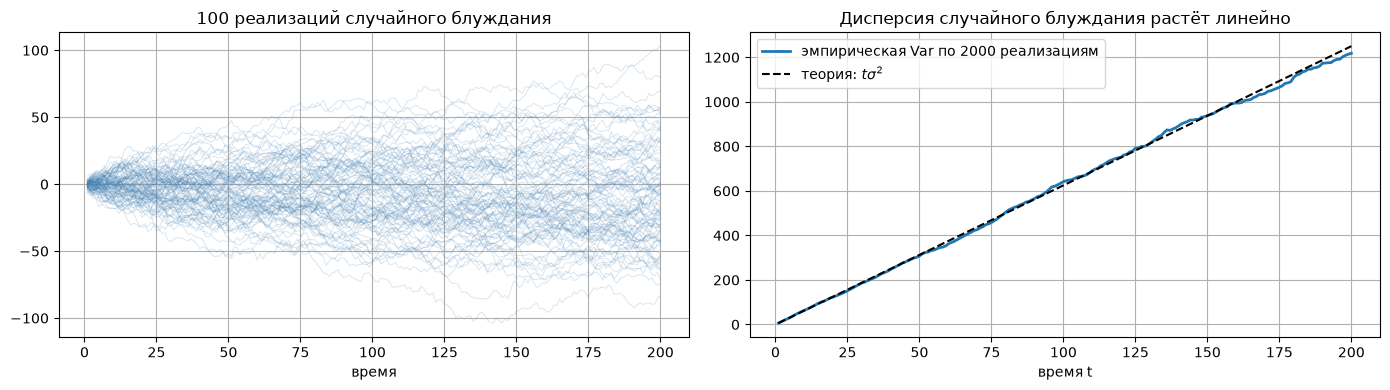

In [65]:
n_sim = 2000
walks = np.cumsum(rng.normal(0, sigma_rw, size=(n_sim, n_rw)), axis=1)
t_grid = np.arange(1, n_rw + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t_grid, walks[:100].T, color="steelblue", alpha=0.2, lw=0.7)
axes[0].set_title("100 реализаций случайного блуждания")
axes[0].set_xlabel("время")

axes[1].plot(t_grid, walks.var(axis=0), lw=2, label="эмпирическая Var по 2000 реализациям")
axes[1].plot(t_grid, t_grid * sigma_rw**2, "k--", lw=1.5, label=r"теория: $t\sigma^2$")
axes[1].set_title("Дисперсия случайного блуждания растёт линейно")
axes[1].set_xlabel("время t")
axes[1].legend()
plt.tight_layout()
plt.show()

Эмпирическая кривая ложится на теоретическую прямую $t\sigma^2$.

**Вердикт: нестационарен.** Нарушен пункт 2 (дисперсия растёт), и вместе
с ним пункт 3: $\mathrm{cov}(y_t, y_{t+h}) = t\sigma^2$ зависит от $t$, а
не только от $h$.

🔍 Обратите внимание на левую картинку: веер расходится в точности так же,
как в разделе 0. Это не совпадение — там был тот же процесс, записанный
как AR(1) с $\varphi = 1$.

## 2.3. Гетероскедастичный ряд

Теперь нарушим **только** пункт 2, оставив всё остальное в порядке.
Склеим два куска белого шума с разными стандартными отклонениями.

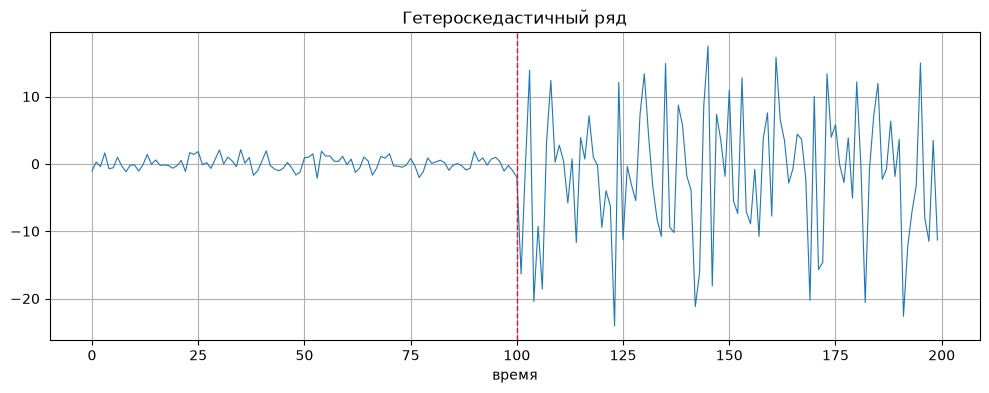

std первой половины:  0.97
std второй половины:  9.78


In [66]:
level_1 = rng.normal(loc=0, scale=1.0, size=100)
level_2 = rng.normal(loc=0, scale=10.0, size=100)
heteroscedastic = pd.Series(np.append(level_1, level_2))

heteroscedastic.plot(title="Гетероскедастичный ряд", xlabel="время", lw=0.8)
plt.axvline(100, color="crimson", ls="--", lw=1)
plt.show()

print(f"std первой половины:  {heteroscedastic.head(100).std():.2f}")
print(f"std второй половины:  {heteroscedastic.tail(100).std():.2f}")

**Вердикт: нестационарен.** Среднее постоянно (ноль), автокорреляций нет,
периодики нет — но дисперсия меняется во времени, и одного этого
достаточно.

🔍 Это важный случай, потому что **разность его не лечит**: взяв
$\Delta y_t$, мы получим ряд, у которого дисперсия по-прежнему скачет в
точке 100. Гетероскедастичность лечат преобразованием (логарифм,
Бокс-Кокс) — и именно поэтому в ноутбуке `03` стабилизация дисперсии идёт
**перед** выбором числа разностей, а не после.

## 2.4. Ряд с сезонностью

Детерминированная синусоида с фиксированным периодом 12.

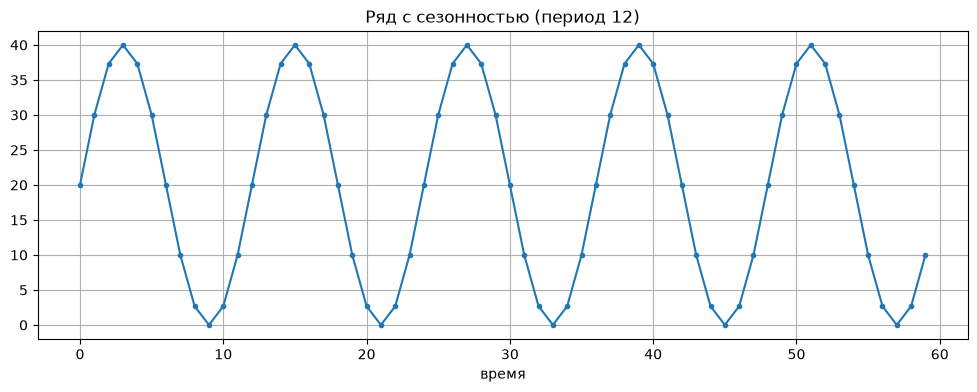

In [67]:
time = np.arange(240)  # 20 полных циклов по 12
seasonal = pd.Series(20 + 20 * np.sin(2 * np.pi * time / 12))

seasonal.head(60).plot(title="Ряд с сезонностью (период 12)", xlabel="время", marker="o", ms=3)
plt.show()

Стационарен ли он? Среднее за **полный** цикл всегда одно и то же (здесь
— 20). Но среднее за половину цикла или за любой отрезок, не кратный
периоду, зависит от того, где именно этот отрезок начинается. То есть
$\mathbb{E}[y_t]$ зависит от $t$ — пункт 1 нарушен.

Покажем это картинкой: скользящее среднее по окну в половину периода.

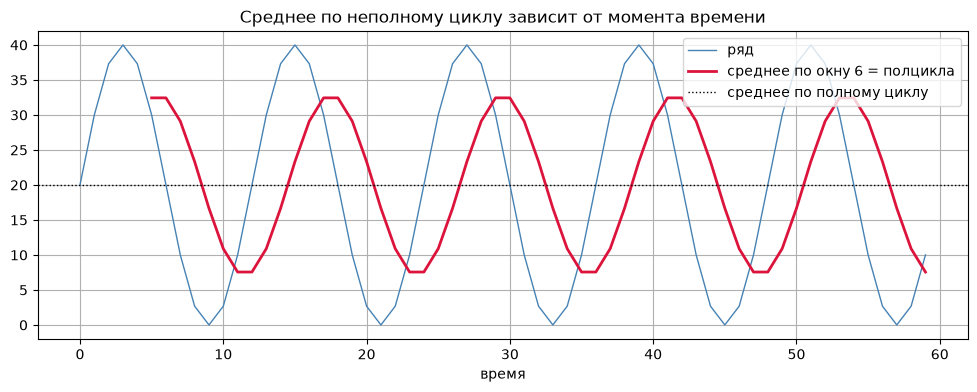

In [68]:
half_cycle = seasonal.rolling(6).mean()

plt.figure(figsize=(12, 4))
plt.plot(seasonal.head(60), color="steelblue", lw=1, label="ряд")
plt.plot(half_cycle.head(60), color="crimson", lw=2, label="среднее по окну 6 = полциклa")
plt.axhline(20, color="black", ls=":", lw=1, label="среднее по полному циклу")
plt.title("Среднее по неполному циклу зависит от момента времени")
plt.xlabel("время")
plt.legend()
plt.show()

Красная кривая колеблется — значит, «локальное среднее» не константа.
А чёрный пунктир (среднее по полному циклу) действительно постоянен.

**Вердикт: нестационарен.** Нарушен пункт 1: среднее зависит от фазы
цикла, то есть от времени.

🔍 Заметьте: дисперсия здесь как раз постоянна, тренда нет, ряд
ограничен. Единственная проблема — периодическая зависимость среднего от
$t$. Лечится сезонной разностью $y_t - y_{t-12}$ (ноутбук `03`, раздел
про мостик к семинару 5).

## 2.5. Синус со случайной фазой — периодический, но стационарный

А теперь обещанный контрпример к пункту 4. Рассмотрим тот же синус, но с
**случайной фазой**:

$$y_t = \mu + R\,\sin(\lambda t + \psi), \qquad \psi \sim U[-\pi, \pi],$$

где $\mu$ — среднее, $R$ — амплитуда, $\lambda$ — частота, а фаза $\psi$
разыгрывается один раз и одинакова для всего ряда.

* Является ли сигнал периодическим? Да.
* Является ли он слабо стационарным? Разберёмся.

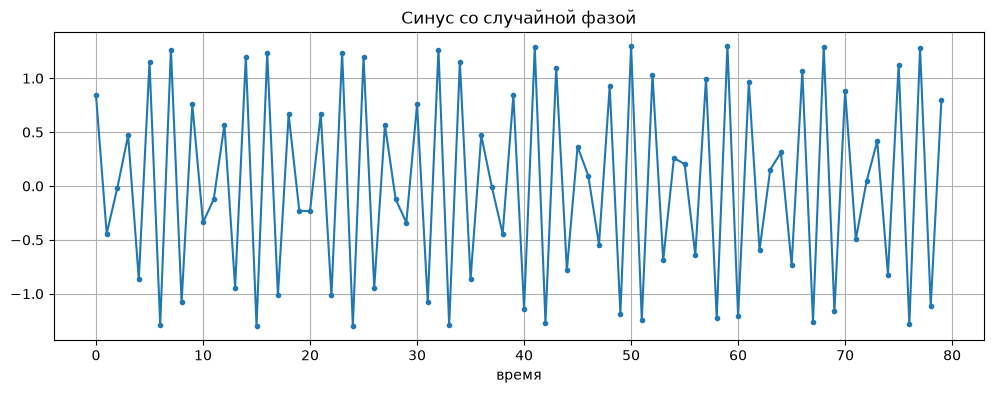

In [69]:
R, lamb = 1.3, 3.5
psi = rng.uniform(-np.pi, np.pi)  # одна фаза на всю траекторию
cyc = pd.Series(R * np.sin(lamb * time + psi))

cyc.head(80).plot(title="Синус со случайной фазой", xlabel="время", marker="o", ms=3)
plt.show()

### Условие 1: постоянное среднее

Матожидание берётся по случайной фазе $\psi$. Из-за симметрии синуса
каждому значению $\psi$, дающему положительный вклад, отвечает значение,
дающее ровно такой же отрицательный. Поэтому
$\mathbb{E}[\sin(\lambda t + \psi)] = 0$, и среднее ряда равно $\mu$ —
константе, не зависящей от $t$. Проверим численным интегрированием при
произвольно взятом $t$.

In [70]:
t_fixed = 4


def sine_at_psi(psi_val):
    """Значение R·sin(λt + ψ) с плотностью U[-π, π] — под интеграл для матожидания."""
    return R * np.sin(lamb * t_fixed + psi_val) / (2 * np.pi)


mean_num, _ = quad(sine_at_psi, -np.pi, np.pi)
print(f"E[R·sin(λt + ψ)] = {mean_num:.2e}   (теория: 0)")

E[R·sin(λt + ψ)] = 1.30e-16   (теория: 0)


### Условие 2: постоянная дисперсия

Так как $\mathbb{E}[Y] = 0$, дисперсия равна $\mathbb{E}[Y^2]$:

$$\mathrm{Var}\big(\sin(\lambda t + \psi)\big)
  = \mathbb{E}\big[\sin^2(\lambda t + \psi)\big]
  = \frac{1}{2\pi}\int_{-\pi}^{\pi} \sin^2(\lambda t + \psi)\, d\psi
  = \frac{1}{2\pi}\cdot\pi = \frac{1}{2}.$$

Значит, $\mathrm{Var}(R\sin(\lambda t + \psi)) = R^2/2$ — константа,
от $t$ не зависит.

<img src="../pic/int.png" style="width: 15%; display: block; margin: auto;">

In [71]:
def sine_squared_at_psi(psi_val):
    return (R * np.sin(lamb * t_fixed + psi_val)) ** 2 / (2 * np.pi)


var_num, _ = quad(sine_squared_at_psi, -np.pi, np.pi)
print(f"Var[R·sin(λt + ψ)] = {var_num:.4f}   (теория: R²/2 = {R**2 / 2:.4f})")

Var[R·sin(λt + ψ)] = 0.8450   (теория: R²/2 = 0.8450)


### Условие 3: автоковариация зависит только от лага

$$\mathrm{cov}(y_t, y_{t+k})
  = R^2\,\mathbb{E}\big[\sin(\lambda t + \psi)\sin(\lambda(t+k) + \psi)\big].$$

Воспользуемся тождеством
$\sin A \sin B = \tfrac{1}{2}\big[\cos(A - B) - \cos(A + B)\big]$:

$$
\begin{aligned}
\mathrm{cov}(y_t, y_{t+k})
&= \frac{R^2}{2}\,\mathbb{E}\big[\cos(\lambda k)\big]
 - \frac{R^2}{2}\,\mathbb{E}\big[\cos(2\lambda t + 2\psi + \lambda k)\big] \\
&= \frac{R^2}{2}\cos(\lambda k) - 0
 = \frac{R^2}{2}\cos(\lambda k).
\end{aligned}
$$

Второе слагаемое обнуляется по тем же соображениям симметрии, что и
среднее. Итог: автоковариация зависит **только от лага $k$** и не зависит
от $t$. Условие 3 выполнено.

Проверим это симуляцией по ансамблю: разыграем много траекторий с
независимыми фазами и посчитаем ковариацию между моментами $t$ и $t+k$.

In [72]:
n_traj = 20000
psis = rng.uniform(-np.pi, np.pi, n_traj)
k_grid = np.arange(0, 13)

emp_cov = [
    np.mean(R * np.sin(lamb * 4 + psis) * R * np.sin(lamb * (4 + k) + psis)) for k in k_grid
]
theo_cov = R**2 / 2 * np.cos(lamb * k_grid)

pd.DataFrame(
    {"эмпирическая cov": np.round(emp_cov, 4), "теория R²/2·cos(λk)": np.round(theo_cov, 4)},
    index=pd.Index(k_grid, name="лаг k"),
).T

лаг k,0,1,2,3,4,5,6,7,8,9,10,11,12
эмпирическая cov,0.8435,-0.7895,0.6352,-0.4001,0.1142,0.1862,-0.4630,0.6809,-0.8123,0.8404,-0.7618,0.5863,-0.3363
теория R²/2·cos(λk),0.8450,-0.7913,0.6370,-0.4018,0.1155,0.1854,-0.4628,0.6814,-0.8134,0.8420,-0.7636,0.5882,-0.3380


Числа совпадают до третьего знака.

**Вердикт: стационарен** — несмотря на явную периодичность на графике.

> 🔑 **Периодичность сама по себе не нарушает слабую стационарность.**
> Нарушает её *детерминированная* сезонность, из-за которой среднее
> становится функцией времени (раздел 2.4). Если же фаза случайна, то,
> усредняя по процессу, мы не можем сказать, где мы находимся внутри
> цикла, — и среднее оказывается постоянным.

🔍 Практическое следствие: **увидев на графике колебания, не спешите
объявлять ряд нестационарным.** Спросите себя, фиксирован ли период и
привязаны ли пики к календарю. Пик каждый декабрь — это сезонность
(пункт 4 нарушен). Пики «примерно раз в 9–11 лет» — это цикл, и он
стационарности не мешает. Ровно этот случай мы встретим на реальных
данных в разделе 3.

## 2.6. AR(1): один коэффициент решает всё

**Авторегрессия первого порядка** — процесс с памятью в один шаг:

$$y_t = \varphi_1 y_{t-1} + \varepsilon_t.$$

Мы уже видели два его частных случая: $\varphi_1 = 0$ — это белый шум,
$\varphi_1 = 1$ — случайное блуждание. Условие стационарности AR(1):
$|\varphi_1| < 1$ (строгий вывод — в семинаре 2, ноутбук `01`).

Сгенерируем три процесса. Для симуляции возьмём `ArmaProcess` из
`statsmodels`.

🔍 **Ловушка со знаком.** `ArmaProcess` принимает коэффициенты
характеристического полинома, а он записывается как
$1 - \varphi_1 L - \varphi_2 L^2 - \dots$, поэтому AR-коэффициенты
передаются **с обратным знаком** и с единицей в начале:
`ar=[1, -phi]` задаёт процесс с $\varphi_1 = \varphi$. 

AR(1), φ = 0.7      isstationary = True
AR(1), φ = -0.8     isstationary = True
AR(1), φ = 0.99     isstationary = True


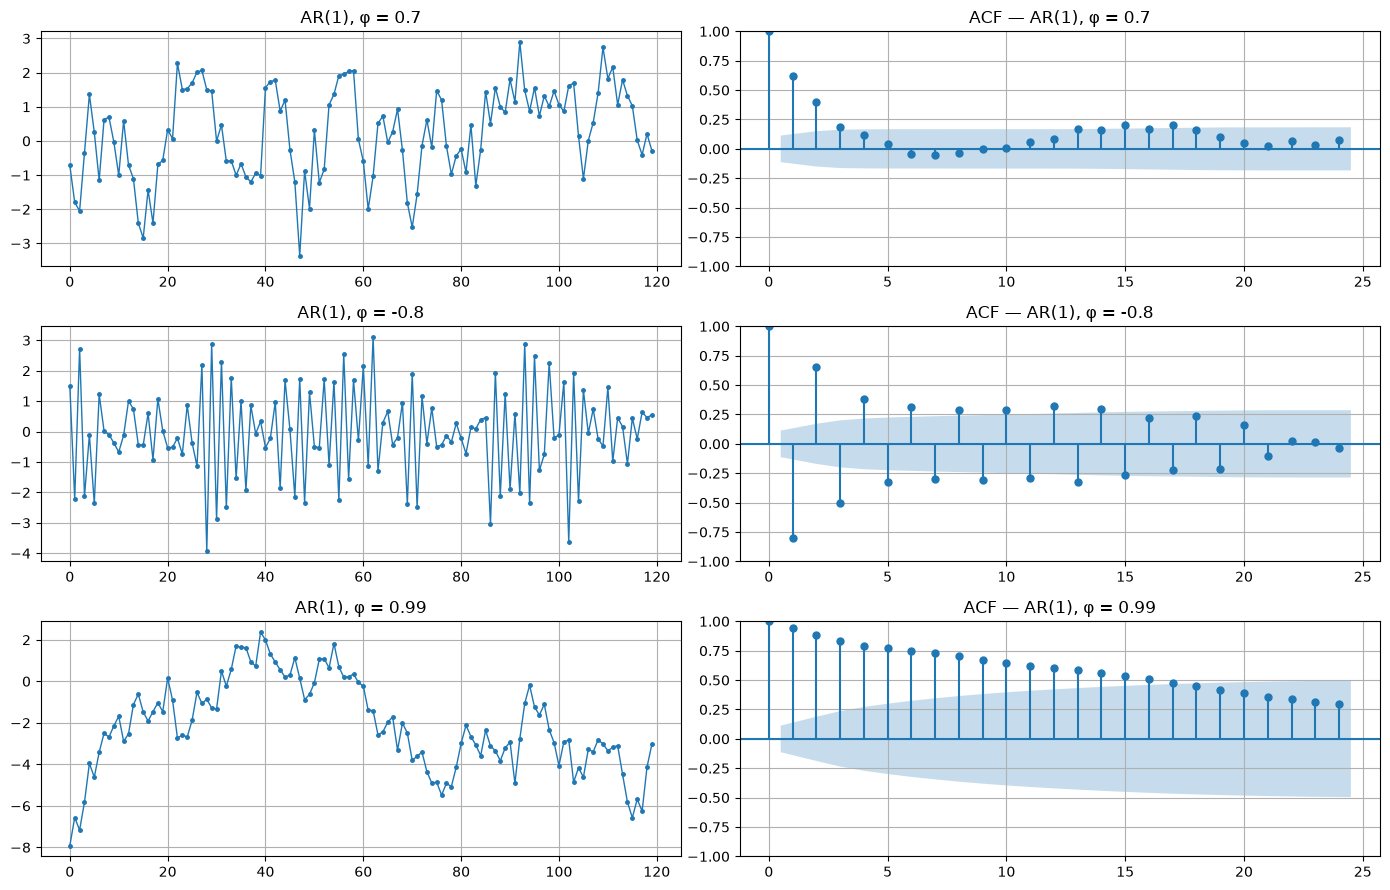

In [73]:
ar_specs = {"AR(1), φ = 0.7": 0.7, "AR(1), φ = -0.8": -0.8, "AR(1), φ = 0.99": 0.99}

ar_samples = {}
for label, phi in ar_specs.items():
    process = ArmaProcess(ar=[1, -phi], ma=[1])
    ar_samples[label] = pd.Series(process.generate_sample(nsample=300, burnin=1000))
    print(f"{label:18s}  isstationary = {process.isstationary}")

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for row, (label, sample) in enumerate(ar_samples.items()):
    axes[row, 0].plot(sample.head(120), lw=1, marker="o", ms=2.5)
    axes[row, 0].set_title(label)
    plot_acf(sample, lags=24, ax=axes[row, 1], title=f"ACF — {label}")
plt.tight_layout()
plt.show()

Три очень разных характера при одном и том же уравнении:

* **$\varphi = 0.7$** — ряд «инерционный»: после отклонения вверх он
  какое-то время остаётся наверху. ACF затухает плавно и экспоненциально,
  все автокорреляции положительны ($\rho_k = \varphi^k$).
* **$\varphi = -0.8$** — ряд **осциллирует**: за высоким значением почти
  всегда идёт низкое. ACF **знакопеременная**: $\rho_k = (-0.8)^k$, то есть
  $-0.8,\ +0.64,\ -0.51, \dots$ Пилообразная ACF — характерный отпечаток
  отрицательного AR-коэффициента, его стоит научиться узнавать.
* **$\varphi = 0.99$** — формально стационарен, но на глаз неотличим от
  случайного блуждания: возврат к среднему настолько медленный, что на
  отрезке в 300 наблюдений его просто не видно. ACF затухает так вяло,
  что на 24 лагах затухания не заметно вовсе.

> 🔑 Третий случай — фундаментальная трудность всей темы: **на конечной
> выборке «стационарный с $\varphi = 0.99$» и «нестационарный» практически
> неразличимы.** В ноутбуке `02` мы измерим это количественно, посчитав
> мощность теста ADF.

## 2.7. Детерминированный и стохастический тренд

Последняя пара — два ряда, которые на графике выглядят похоже (оба
«растут»), но устроены принципиально по-разному и лечатся по-разному.

**Детерминированный тренд** — прямая плюс шум вокруг неё:

$$y_t = \beta_0 + \beta_1 t + \varepsilon_t.$$

Ряд нестационарен (среднее зависит от $t$), но отклонения от прямой
затухают мгновенно: сдвинувшись вверх, ряд на следующем шаге вернётся к
линии. Такой ряд называют **trend-stationary** — стационарным
относительно тренда.

**Стохастический тренд** — случайное блуждание со сносом:

$$y_t = \beta_0 + y_{t-1} + \varepsilon_t.$$

Здесь нет никакой линии, к которой ряд обязан возвращаться: уровень сам по
себе случайно дрейфует. Такой ряд называют **difference-stationary** —
стационарным после взятия разности.

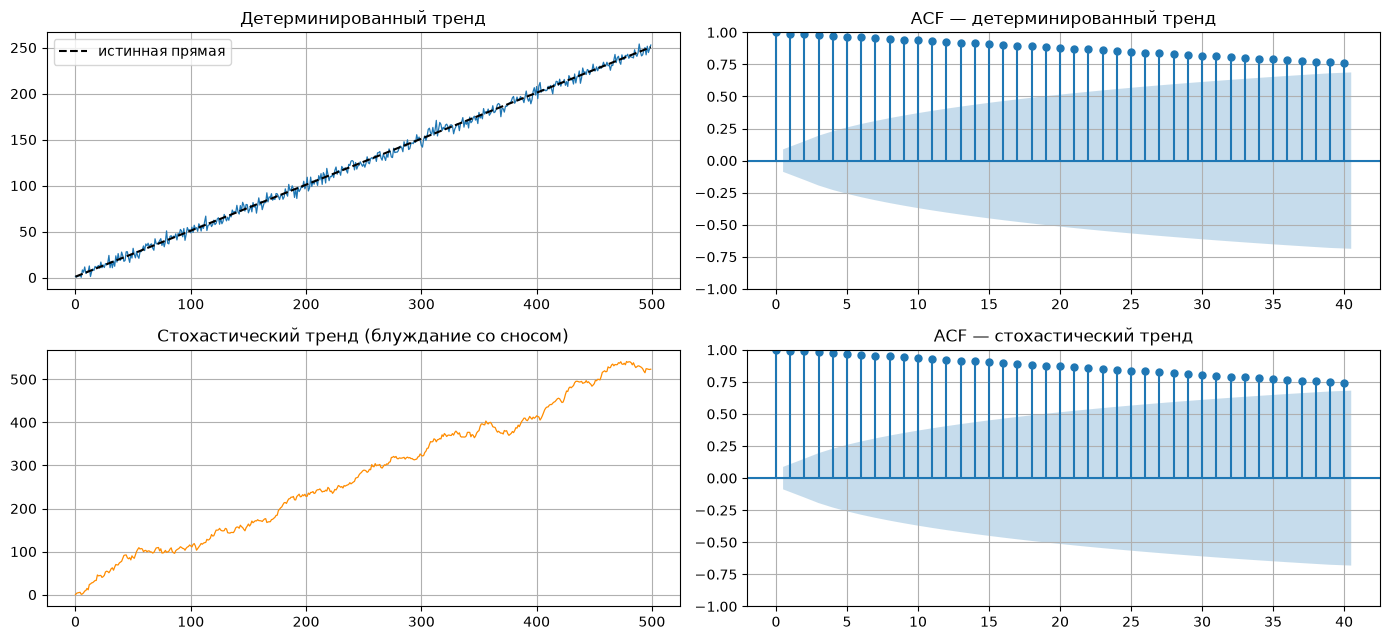

In [74]:
beta_0, beta_1, sigma = 1.0, 0.5, 4.0
n_steps = 500

t_axis = np.arange(n_steps)
y_det = pd.Series(beta_0 + beta_1 * t_axis + rng.normal(0, sigma, n_steps))
y_stoch = pd.Series(beta_0 * np.arange(1, n_steps + 1) + np.cumsum(rng.normal(0, sigma, n_steps)))

fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))
axes[0, 0].plot(y_det, lw=0.9)
axes[0, 0].plot(beta_0 + beta_1 * t_axis, "k--", lw=1.5, label="истинная прямая")
axes[0, 0].set_title("Детерминированный тренд")
axes[0, 0].legend()
plot_acf(y_det, lags=40, ax=axes[0, 1], title="ACF — детерминированный тренд")

axes[1, 0].plot(y_stoch, lw=0.9, color="darkorange")
axes[1, 0].set_title("Стохастический тренд (блуждание со сносом)")
plot_acf(y_stoch, lags=40, ax=axes[1, 1], title="ACF — стохастический тренд")
plt.tight_layout()
plt.show()

🔍 Первое неприятное открытие: **ACF у обоих рядов выглядит одинаково** —
медленное, почти линейное затухание. Автокорреляционная функция не
различает эти два случая, потому что видит только общее «уползание»
уровня. Отличить их можно тестами (ноутбук `02`, спецификация `ct`) или
содержательными соображениями о природе данных.

Второе: разность «лечит» их по-разному. Посмотрим на $\Delta y_t$ в обоих
случаях.

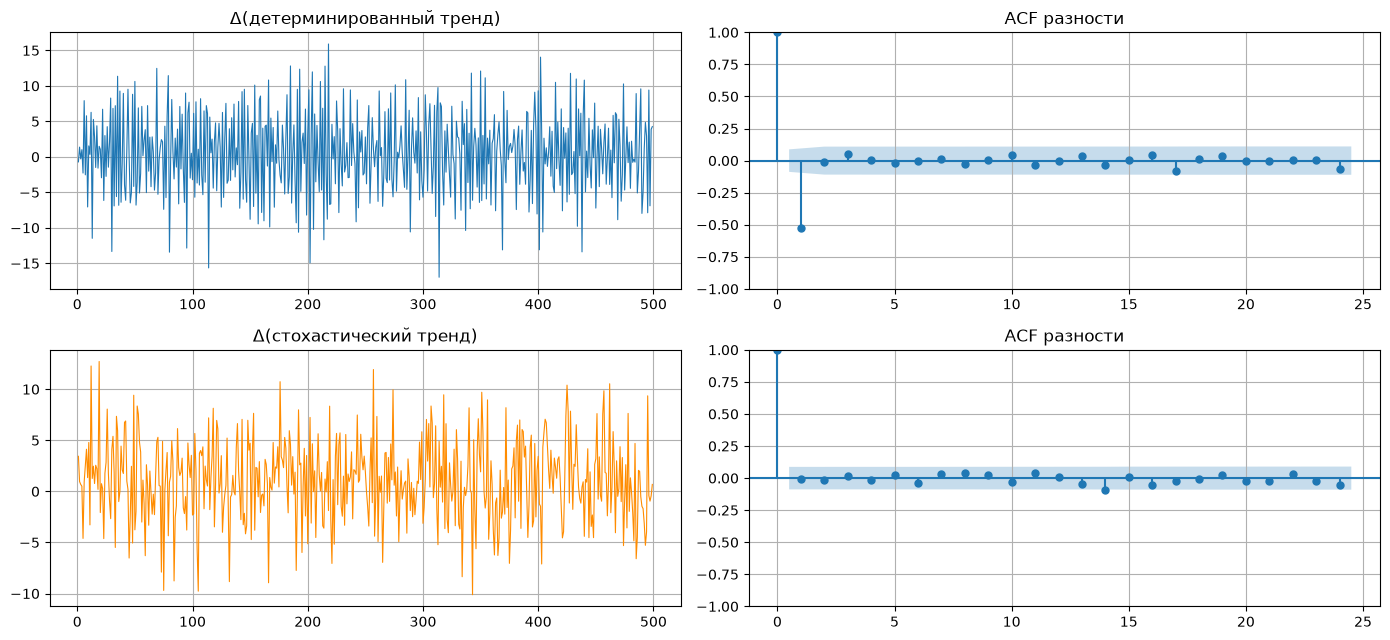

ρ₁ разности детерминированного тренда: -0.523
ρ₁ разности стохастического тренда:   -0.009


In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))
axes[0, 0].plot(y_det.diff().dropna(), lw=0.8)
axes[0, 0].set_title("Δ(детерминированный тренд)")
plot_acf(y_det.diff().dropna(), lags=24, ax=axes[0, 1], title="ACF разности")

axes[1, 0].plot(y_stoch.diff().dropna(), lw=0.8, color="darkorange")
axes[1, 0].set_title("Δ(стохастический тренд)")
plot_acf(y_stoch.diff().dropna(), lags=24, ax=axes[1, 1], title="ACF разности")
plt.tight_layout()
plt.show()

print(f"ρ₁ разности детерминированного тренда: {y_det.diff().autocorr(1):+.3f}")
print(f"ρ₁ разности стохастического тренда:   {y_stoch.diff().autocorr(1):+.3f}")

Для **стохастического** тренда разность даёт чистый белый шум — это
правильное лечение, потому что $\Delta y_t = \beta_0 + \varepsilon_t$ по
построению.

Для **детерминированного** тренда разность тоже убирает рост, но платой
становится наведённая отрицательная автокорреляция первого порядка
$\rho_1 \approx -0.5$: ведь
$\Delta y_t = \beta_1 + \varepsilon_t - \varepsilon_{t-1}$ — это MA(1) с
$\theta_1 = -1$. Мы испортили ряд там, где достаточно было вычесть прямую.

> 🔑 **Разность — не универсальное лекарство.** Ряду с детерминированным
> трендом нужна регрессия на время (детрендирование), ряду со
> стохастическим — разность. Спутать их значит либо оставить
> нестационарность, либо получить **сверхдифференцированный** ряд.

Обе ошибки и их последствия мы доведём до конца в ноутбуке `03`.

## 2.8. Итог зоопарка

Соберём всё в одну таблицу — она же шпаргалка для раздела 3.

| Ряд | Стационарен? | Какой пункт чек-листа нарушен | Чем лечится |
|---|---|---|---|
| Белый шум | ✅ да | — | не нужно |
| Случайное блуждание | ❌ нет | 2 (дисперсия растёт как $t\sigma^2$) | разность |
| Гетероскедастичный | ❌ нет | 2 (дисперсия меняется) | лог / Бокс-Кокс |
| Детерминированная сезонность | ❌ нет | 1 (среднее зависит от фазы) | сезонная разность |
| Синус со случайной фазой | ✅ да | — | не нужно |
| AR(1), $\|\varphi\| < 1$ | ✅ да | — | не нужно |
| Детерминированный тренд | ❌ нет | 1 (среднее растёт) | вычесть прямую |
| Стохастический тренд | ❌ нет | 1 и 2 | разность |

🔍 Обратите внимание, как часто ответ — «нарушен пункт 2». Дисперсия
ломается чаще, чем кажется, и именно поэтому в правильном порядке
действий (ноутбук `03`) стабилизация дисперсии стоит **первой**.

---
# 3. Диагностика по сводным статистикам

Глаз — хороший, но неформальный инструмент. Первый шаг к воспроизводимости:
разбить ряд на несколько последовательных кусков и сравнить среднее и
дисперсию между ними. Метод грубый, но он даёт числа, которые можно
положить в отчёт.

Идея на картинках:

<img src="../pic/stationary_chunk.png" style="width: 45%; display: block; margin: auto;">
<center>стационарный ряд: облака совпадают</center>

<img src="../pic/nonstationary_chunk.png" style="width: 45%; display: block; margin: auto;">
<center>нестационарный ряд: облака расходятся</center>

Оформим это в функцию, которой будем пользоваться дальше.

In [76]:
def chunk_stats(y, k=10):
    """Разбить ряд на k последовательных кусков и сравнить среднее и дисперсию.

    Грубая, но воспроизводимая проверка пунктов 1 и 2 чек-листа
    стационарности. Столбец `mean` отвечает за постоянство среднего,
    `var` — за постоянство дисперсии.

    Возвращает DataFrame с построчной статистикой по кускам.
    """
    y = pd.Series(y).dropna().to_numpy()
    chunks = np.array_split(y, k)
    return pd.DataFrame(
        {
            "n": [len(c) for c in chunks],
            "mean": [c.mean() for c in chunks],
            "var": [c.var() for c in chunks],
        },
        index=pd.RangeIndex(1, k + 1, name="кусок"),
    )

Проверим её на двух знакомых рядах: синусе со случайной фазой
(стационарен) и случайном блуждании (нет).

In [77]:
stats_cyc = chunk_stats(cyc, k=10)
stats_rw = chunk_stats(rand_walk, k=10)

comparison = pd.concat(
    {"синус со случайной фазой": stats_cyc[["mean", "var"]], "случайное блуждание": stats_rw[["mean", "var"]]},
    axis=1,
)
comparison.round(3)

синус со случайной фазой        случайное блуждание        
                          mean    var                mean     var
кусок                                                            
1                        0.049  0.780              -8.075  34.786
2                       -0.043  0.810              -3.509   9.856
3                        0.010  0.913              -3.276   5.519
4                        0.029  0.868              -3.571  12.107
5                       -0.050  0.771              -4.721  10.269
6                        0.039  0.831               0.571   9.265
7                       -0.002  0.918              -2.068  16.642
8                       -0.035  0.845              -4.045  10.469
9                        0.050  0.769              -7.040   9.198
10                      -0.033  0.853             -13.164  13.561

Читаем таблицу:

* У **синуса** средние по кускам болтаются вокруг нуля, дисперсии — вокруг
  одного и того же значения $R^2/2 \approx 0.85$. Ни в одном столбце нет
  систематического движения.
* У **блуждания** средние по кускам монотонно уползают, а дисперсии
  отличаются в разы. Это ровно то, что предсказывает $\mathrm{Var}(y_t) = t\sigma^2$.

Удобнее сравнивать одним числом — отношением максимума к минимуму.

In [78]:
for name, tbl in [("синус", stats_cyc), ("блуждание", stats_rw)]:
    spread_mean = tbl["mean"].max() - tbl["mean"].min()
    ratio_var = tbl["var"].max() / tbl["var"].min()
    print(f"{name:12s}  размах средних: {spread_mean:7.3f}   max/min дисперсий: {ratio_var:6.2f}")

синус         размах средних:   0.100   max/min дисперсий:   1.19
блуждание     размах средних:  13.735   max/min дисперсий:   6.30


🔍 **Ограничения метода.** Он не строгий и легко обманывается:

* порог «во сколько раз это много» — вопрос вкуса, а не статистики;
* ряд с сезонностью, разбитый на куски, кратные периоду, покажет идеально
  ровные средние — сейчас убедимся;
* метод вообще не смотрит на пункт 3 чек-листа (автокорреляционную
  структуру), а именно она даёт самый практичный сигнал.

Поэтому переходим к третьему инструменту.

In [79]:
chunk_stats(seasonal, k=10)[["mean", "var"]].round(4)

,mean,var
кусок,,
1,20.0,200.0
2,20.0,200.0
3,20.0,200.0
4,20.0,200.0
5,20.0,200.0
6,20.0,200.0
7,20.0,200.0
8,20.0,200.0
9,20.0,200.0


Ряд длиной 240 разбился на 10 кусков по 24 наблюдения — ровно два полных
цикла в каждом. Средние и дисперсии по кускам совпали **до последнего
знака**: по этой таблице ряд выглядит образцово стационарным. А мы знаем
из раздела 2.4, что он нестационарен.

🔍 Это не искусственный случай: месячные данные почти всегда разбивают на
куски по целому числу лет. Сводные статистики систематически слепы к
сезонности — ещё один довод в пользу ACF, которая её видит сразу.

---
# 4. Диагностика по ACF

**Автокорреляционная функция** ряда — это набор корреляций между $y_t$ и
$y_{t-k}$:

$$\rho_k = \frac{\mathrm{cov}(y_t, y_{t-k})}{\mathrm{Var}(y_t)}, \qquad k = 1, 2, 3, \dots$$

Оценивается она как

$$\hat\rho_k = \frac{\sum_{t=k+1}^{n}(y_t - \bar y)(y_{t-k} - \bar y)}
                    {\sum_{t=1}^{n}(y_t - \bar y)^2}.$$

ACF — самый информативный из трёх инструментов, потому что напрямую
смотрит на пункт 3 чек-листа. И у неё есть одно правило, которым мы будем
пользоваться всю неделю.

> 🔑 **Правило 1.** Если ACF **медленно и монотонно** затухает, оставаясь
> положительной на многих лагах, — ряд нестационарен и, скорее всего,
> нужна разность. Если ACF обрывается или затухает быстро (за несколько
> лагов) — ряд похож на стационарный.

Почему это работает? У нестационарного ряда любые два соседних значения
близки просто потому, что уровень успевает сместиться лишь чуть-чуть.
Корреляция между $y_t$ и $y_{t-k}$ остаётся высокой даже при большом $k$,
и ACF «сползает» почти линейно, а не экспоненциально.

## 4.1. Демонстрация: цена GOOGL и её приращения

Возьмём ряд №1 из разминки — цену закрытия акций Google.

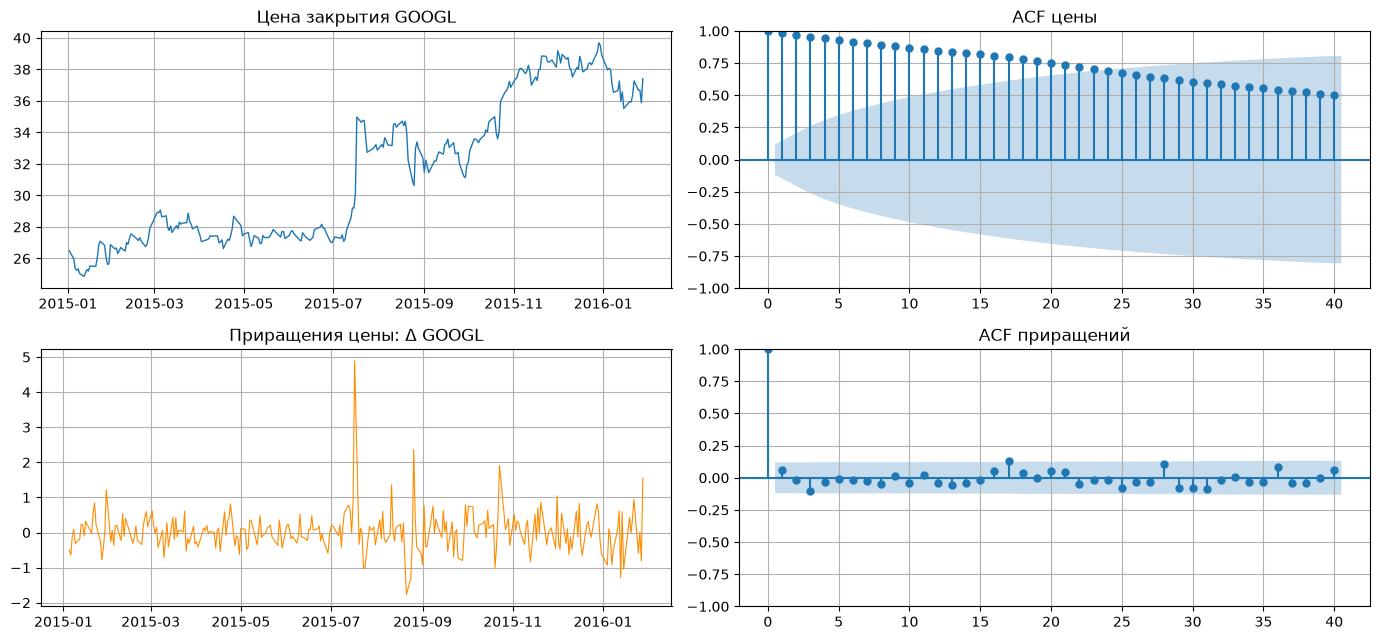

In [80]:
googl = pd.read_csv("../data/GOOGL.csv", parse_dates=["Date"]).set_index("Date")["Close"]
googl_diff = googl.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))

axes[0, 0].plot(googl.index, googl.to_numpy(), lw=1)
axes[0, 0].set_title("Цена закрытия GOOGL")
plot_acf(googl, lags=40, ax=axes[0, 1], title="ACF цены")

axes[1, 0].plot(googl_diff.index, googl_diff.to_numpy(), lw=0.8, color="darkorange")
axes[1, 0].set_title("Приращения цены: Δ GOOGL")
plot_acf(googl_diff, lags=40, ax=axes[1, 1], title="ACF приращений")

plt.tight_layout()
plt.show()

Контраст предельно нагляден:

* **ACF цены** начинается почти с единицы и сползает практически по
  прямой, оставаясь далеко за границей значимости на всех 40 лагах.
  Это эталонная картинка «нужна разность».
* **ACF приращений** — все столбики внутри полосы. Приращения выглядят
  как белый шум.

Посмотрим на конкретные числа первых лагов.

In [81]:
acf_table = pd.DataFrame(
    {
        "ACF цены": acf(googl, nlags=10),
        "ACF приращений": acf(googl_diff, nlags=10),
    },
    index=pd.RangeIndex(0, 11, name="лаг"),
).round(3)
acf_table

,ACF цены,ACF приращений
лаг,,
0,1.000,1.000
1,0.986,0.064
2,0.972,-0.021
3,0.957,-0.105
4,0.943,-0.031
5,0.929,-0.009
6,0.916,-0.018
7,0.904,-0.023
8,0.892,-0.050


У цены $\hat\rho_{10} \approx 0.9$, у приращений — около нуля.

> 🔑 Ряд, у которого **сам ряд** нестационарен, а **его первая разность**
> стационарна, называют интегрированным первого порядка, $I(1)$. В
> обозначении ARIMA(p, d, q) это как раз $d = 1$. Цена почти любого
> финансового актива — типичный $I(1)$-ряд.


## 5.2. Как ACF выглядит у разных типов нестационарности

Соберём отпечатки ACF в одну панель — эту картинку полезно держать перед
глазами при разборе новых данных.

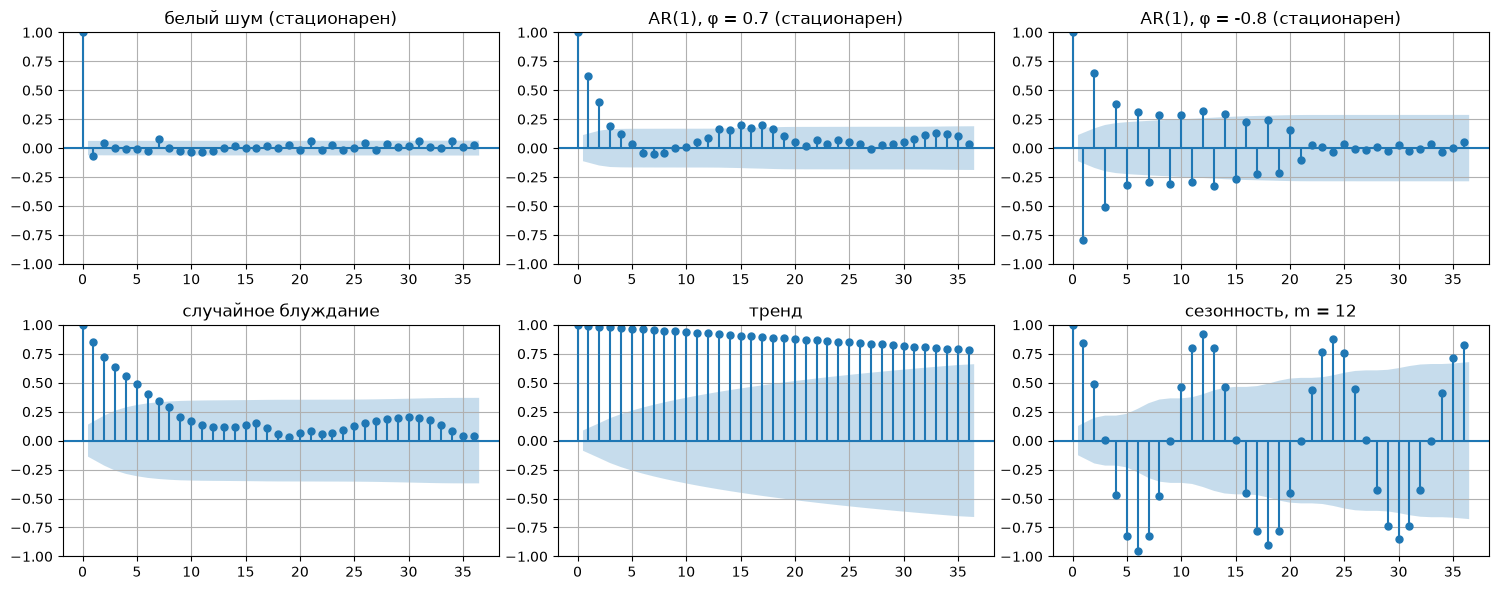

In [82]:
acf_gallery = {
    "белый шум (стационарен)": white_noise,
    "AR(1), φ = 0.7 (стационарен)": ar_samples["AR(1), φ = 0.7"],
    "AR(1), φ = -0.8 (стационарен)": ar_samples["AR(1), φ = -0.8"],
    "случайное блуждание": rand_walk,
    "тренд": y_det,
    "сезонность, m = 12": seasonal + rng.normal(0, 2, len(seasonal)),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, (name, s) in zip(axes.ravel(), acf_gallery.items()):
    plot_acf(pd.Series(s).dropna(), lags=36, ax=ax, title=name)
plt.tight_layout()
plt.show()

Четыре отпечатка, которые стоит выучить:

| Картинка ACF | Диагноз |
|---|---|
| всё внутри полосы | белый шум, моделировать нечего |
| плавное экспоненциальное затухание | AR-структура, ряд стационарен |
| знакопеременное затухание («пила») | AR с отрицательным $\varphi$ |
| медленное почти линейное сползание | **нестационарность, нужна разность** |
| пики на лагах $m, 2m, 3m$ | сезонность с периодом $m$ |

🔍 Важная оговорка: ACF **не** отличает случайное блуждание от
детерминированного тренда (мы видели это в разделе 2.7) — обе картинки
выглядят как медленное сползание. Различить их — задача тестов из
ноутбука `02`.

---
# 6. `tsdisplay`: сквозной инструмент семинара

Панель состоит из трёх частей:

* **сам ряд** — без него ACF читать бессмысленно (см. раздел 2.7);
* **ACF** — прямая корреляция $y_t$ с $y_{t-k}$, включая косвенную,
  передавшуюся по цепочке через промежуточные лаги;
* **PACF** (частная автокорреляция) — та же корреляция, но **очищенная**
  от вклада промежуточных лагов: связь $y_t$ и $y_{t-k}$ при фиксированных
  $y_{t-1}, \dots, y_{t-k+1}$.

🔍 Зачем нужна PACF, если есть ACF? У AR(1) с $\varphi=0.7$ корреляция на
лаге 2 равна $0.49$ — но это не «своя» связь, а эхо: $y_t$ связан с
$y_{t-1}$, а тот с $y_{t-2}$. PACF это эхо убирает и покажет на лаге 2
ноль. В семинаре 2 на этом будет построена вся идентификация порядков:
**обрыв PACF ⇒ AR, обрыв ACF ⇒ MA**. Сегодня нам достаточно того, что
обе функции удобно смотреть рядом.

In [83]:
from sktime.utils.plotting import plot_correlations

def tsdisplay(y, lags=36, title=None, figsize=(13, 6)):
    """Панель «ряд + ACF + PACF» — сквозной инструмент диагностики семинара."""
    fig, ax = plot_correlations(y, lags=lags, suptitle=title, acf_title="ACF", pacf_title="PACF")
    fig = plt.figure(figsize=figsize)
    return fig

Опробуем на трёх рядах: заведомо стационарном, заведомо нестационарном и
реальном.

<Figure size 1300x600 with 0 Axes>

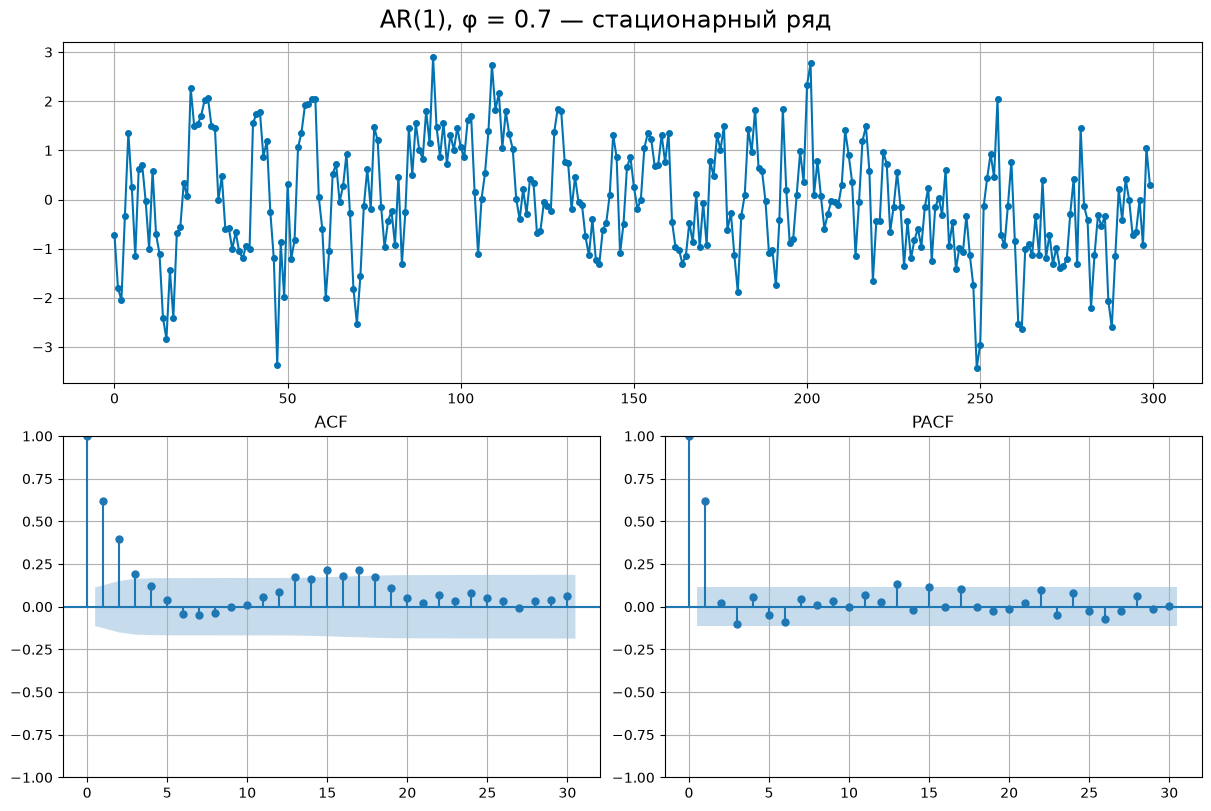

<Figure size 1300x600 with 0 Axes>

In [84]:
tsdisplay(ar_samples["AR(1), φ = 0.7"], lags=30, title="AR(1), φ = 0.7 — стационарный ряд")

ACF затухает экспоненциально, PACF обрывается после первого лага — так
выглядит AR(1). Ряд стационарен.

<Figure size 1300x600 with 0 Axes>

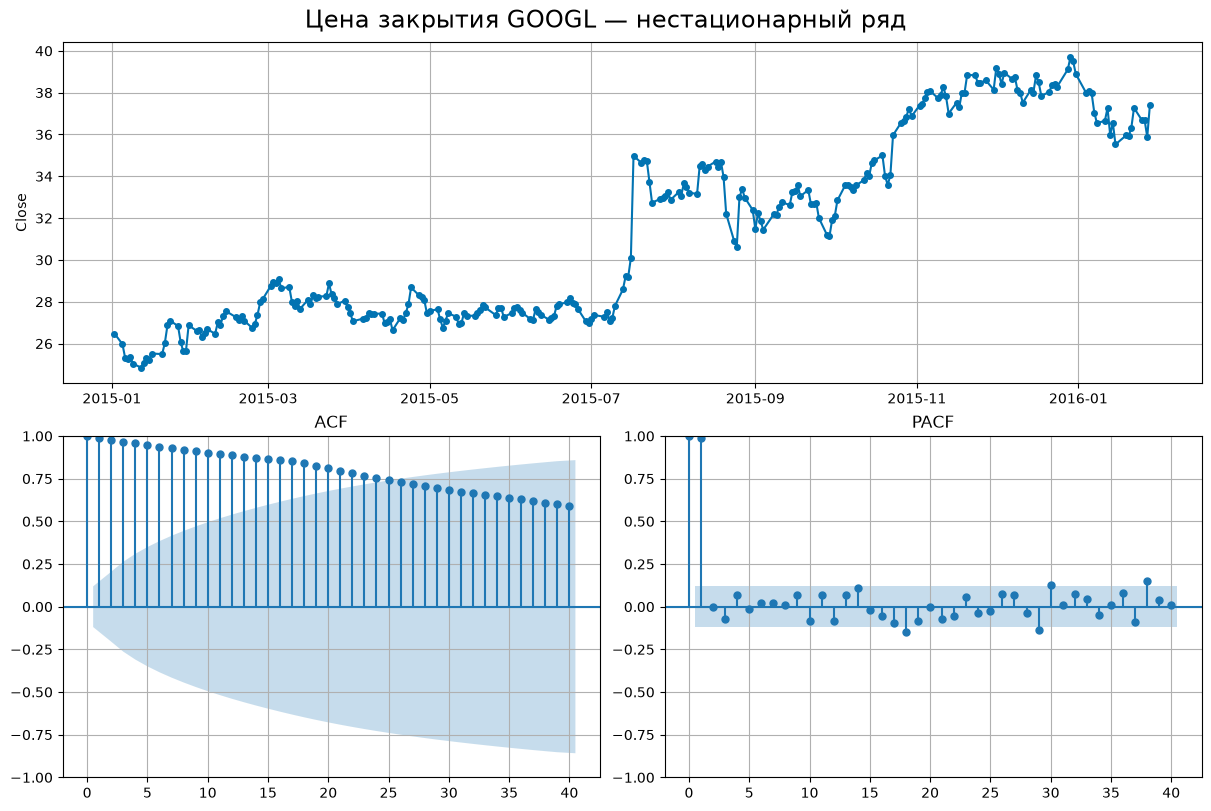

<Figure size 1300x600 with 0 Axes>

In [85]:
tsdisplay(googl, lags=40, title="Цена закрытия GOOGL — нестационарный ряд")

ACF сползает медленно; PACF при этом имеет единственный огромный столбик
на лаге 1, близкий к единице. Комбинация «медленная ACF + PACF с
единственным пиком ≈ 1» — очень характерный признак ряда с единичным
корнем.

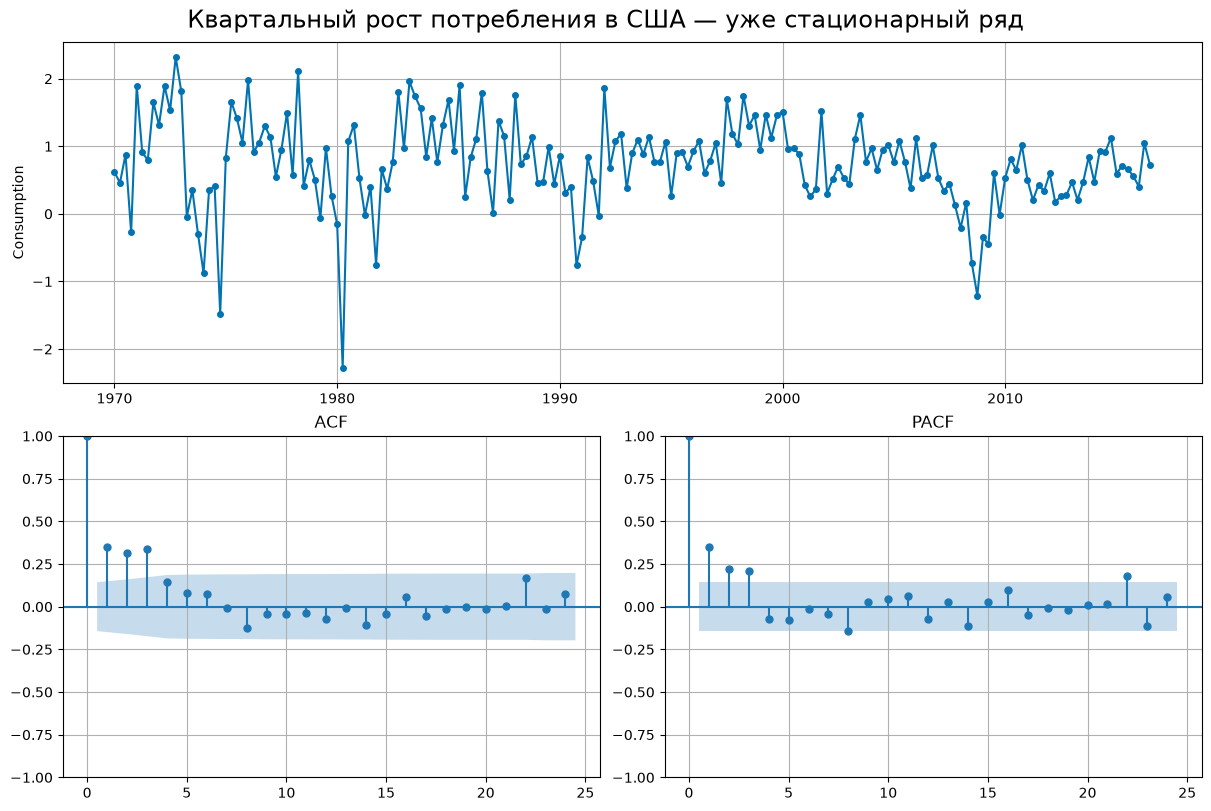

<Figure size 1300x600 with 0 Axes>

In [86]:
tsdisplay(
    pd.read_csv(
        "../data/us_change.csv", parse_dates=["Time"]
    ).set_index("Time")["Consumption"],
    lags=24,
    title="Квартальный рост потребления в США — уже стационарный ряд",
)
plt.show()

Ряд колеблется вокруг постоянного уровня, обе коррелограммы затухают
быстро — но не мгновенно: несколько первых лагов значимы. Это значит, что
ряд стационарен, однако **не** белый шум: в нём есть структура, которую
можно моделировать. Ровно этим и займётся семинар 2.

🔑 Разница между «стационарен» и «белый шум» принципиальна:
стационарность — это условие применимости модели, а не отсутствие
сигнала. Мы приводим ряд к стационарности не для того, чтобы он стал
бессодержательным, а чтобы к нему стали применимы ARMA-модели.

---
# 7. Portmanteau-тесты: проверяем все лаги сразу

(про тесты было в лекции 2)

Вернёмся к оговорке из раздела 2.1. Глядя на коррелограмму, мы принимаем
36 отдельных решений на уровне 5% каждое — и примерно два ложных
срабатывания гарантированы. Нужен один тест на вопрос: **«есть ли
автокорреляция хоть на каком-нибудь из первых $m$ лагов?»**

Такие тесты называются **portmanteau** (франц. «чемодан» — в них
«упакованы» сразу все лаги).

## 7.1. Ljung-Box и Box-Pierce

$$H_0: \rho_1 = \rho_2 = \dots = \rho_m = 0
  \qquad \text{против} \qquad H_1: \exists\, k \le m: \rho_k \neq 0.$$

Статистика Бокса-Пирса — просто сумма квадратов автокорреляций:

$$Q_{BP} = n \sum_{k=1}^{m} \hat\rho_k^2 \;\sim\; \chi^2_m.$$

Статистика Льюнга-Бокса — та же идея с поправкой на конечную выборку,
которая даёт лучшее приближение к $\chi^2$ на коротких рядах:

$$Q_{LB} = n(n+2) \sum_{k=1}^{m} \frac{\hat\rho_k^2}{n-k} \;\sim\; \chi^2_m.$$

🔍 На практике всегда берут Льюнга-Бокса: при больших $n$ они почти
совпадают, при малых $Q_{LB}$ точнее. `statsmodels` считает обе сразу
по флагу `boxpierce=True`.

Прогоним на белом шуме — здесь $H_0$ верна и отвергаться не должна.

In [87]:
acorr_ljungbox(white_noise, lags=[5, 10, 20], boxpierce=True).round(4)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
5,7.2960,0.1995,7.2713,0.2012
10,16.4538,0.0874,16.3434,0.0902
20,19.9209,0.4629,19.7536,0.4734


Все p-value велики — гипотезу об отсутствии автокорреляции не отвергаем,
что и требовалось. Теперь тот же тест на AR(1), где автокорреляция
заведомо есть.

In [88]:
acorr_ljungbox(ar_samples["AR(1), φ = 0.7"], lags=[5, 10, 20], boxpierce=True).round(4)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
5,179.7486,0.0,177.6840,0.0
10,181.4786,0.0,179.3625,0.0
20,249.4088,0.0,243.3272,0.0


p-value машинный ноль — $H_0$ уверенно отвергнута. Тест работает.

🔍 **Как выбирать $m$.** Слишком мало — можно пропустить автокорреляцию на
дальних лагах; слишком много — статистика «разбавляется» нулевыми
слагаемыми и теряет мощность. Рекомендация Хайндмана: $m = 10$ для
несезонных рядов и $m = 2m_{\text{сезон}}$ для сезонных, но не больше
$n/5$.

## 7.2. Ловушка: тест на остатках модели

Главное практическое применение Ljung-Box — не исходный ряд, а **остатки
подогнанной модели**: если модель забрала всю линейную динамику, её
остатки должны быть белым шумом.

Но здесь есть подвох, на котором спотыкаются почти все. Остатки — это не
наблюдаемый ряд, а результат подгонки: мы **потратили** часть информации
на оценку $p + q$ параметров. Поэтому число степеней свободы у $\chi^2$
должно быть не $m$, а $m - (p + q)$. В `statsmodels` за это отвечает
аргумент `model_df`.

Посмотрим, какова цена ошибки. Подгоним заведомо недостаточную модель
AR(1) к ряду AR(3) — остатки обязаны сохранить автокорреляцию.

In [89]:
from statsmodels.tsa.arima.model import ARIMA

ar3 = pd.Series(
    ArmaProcess(ar=[1, -0.5, -0.25, -0.2], ma=[1]).generate_sample(nsample=300, burnin=1000)
)

fit_ar3 = ARIMA(ar3, order=(3, 0, 0)).fit()
fit_ar1 = ARIMA(ar3, order=(1, 0, 0)).fit()

lb_comparison = pd.DataFrame(
    {
        "Q (lb_stat)": [
            acorr_ljungbox(fit_ar3.resid, lags=[10])["lb_stat"].iloc[0],
            acorr_ljungbox(fit_ar1.resid, lags=[10])["lb_stat"].iloc[0],
        ],
        "p-value без model_df (df = 10)": [
            acorr_ljungbox(fit_ar3.resid, lags=[10])["lb_pvalue"].iloc[0],
            acorr_ljungbox(fit_ar1.resid, lags=[10])["lb_pvalue"].iloc[0],
        ],
        "p-value с model_df (df = 10 − p)": [
            acorr_ljungbox(fit_ar3.resid, lags=[10], model_df=3)["lb_pvalue"].iloc[0],
            acorr_ljungbox(fit_ar1.resid, lags=[10], model_df=1)["lb_pvalue"].iloc[0],
        ],
    },
    index=["AR(3) — верная спецификация", "AR(1) — недоспецификация"],
).round(4)
lb_comparison

,Q (lb_stat),p-value без model_df (df = 10),p-value с model_df (df = 10 − p)
AR(3) — верная спецификация,14.2894,0.1602,0.0463
AR(1) — недоспецификация,51.0207,0.0000,0.0000


Диагнозы поставлены верно в обоих случаях: у правильной модели остатки —
белый шум, у недоспецифицированной автокорреляция уверенно обнаружена.
Здесь обе версии теста согласны, потому что оба случая крайние: статистика
$Q$ либо совсем маленькая, либо огромная.

Проблема возникает в промежуточной зоне. Механизм ошибки простой: одна и
та же статистика $Q$ сравнивается с разными распределениями — $\chi^2_{10}$
вместо правильного $\chi^2_{7}$. Посмотрим, к чему это приводит.

In [90]:
from scipy.stats import chi2

q_grid = np.array([8.0, 12.0, 14.0, 16.0, 18.0, 20.0])
df_effect = pd.DataFrame(
    {
        "p-value, df = 10 (без model_df)": 1 - chi2.cdf(q_grid, 10),
        "p-value, df = 7 (верно)": 1 - chi2.cdf(q_grid, 7),
    },
    index=pd.Index(q_grid, name="Q"),
).round(4)
df_effect["вывод расходится?"] = (df_effect.iloc[:, 0] > 0.05) != (df_effect.iloc[:, 1] > 0.05)
df_effect

,"p-value, df = 10 (без model_df)","p-value, df = 7 (верно)",вывод расходится?
Q,,,
8.0,0.6288,0.3326,False
12.0,0.2851,0.1006,False
14.0,0.1730,0.0512,False
16.0,0.0996,0.0251,True
18.0,0.0550,0.0120,True
20.0,0.0293,0.0056,False


В строках $Q = 16$ и $Q = 18$ два варианта дают **противоположные
решения** на уровне 5%: неверная версия говорит «остатки в порядке»
($p = 0.10$ и $p = 0.055$), верная — «автокорреляция есть, вернитесь и
улучшите модель» ($p = 0.025$ и $p = 0.012$). Значения $Q$ именно такого
порядка встречаются в реальной работе постоянно, а разница в p-value
доходит до четырёх раз.

> 🔑 На остатках подогнанной модели всегда указывайте
> `model_df = p + q`. Без него тест смещён в сторону «всё хорошо»
> (p-value завышено), и вы рискуете принять недоспецифицированную модель.



---
# Итоги

* **Зачем.** Прогноз стационарного ряда сходится к среднему с ограниченным
  интервалом; прогноз нестационарного не сходится ни к чему, а интервал
  растёт как $\sqrt{h}$. Буква `d` в ARIMA существует ради приведения ряда
  к стационарности (раздел 0).
* **Определение.** Строгая стационарность — инвариантность распределений к
  сдвигу, на данных непроверяема. Работаем со слабой: постоянное среднее,
  постоянная дисперсия, ковариация зависит только от лага (раздел 1).
* **Чек-лист из 4 пунктов:** среднее, дисперсия, автокорреляционная
  структура, периодика. Четвёртый пункт — с оговоркой.
* **Зоопарк (раздел 2).** Стационарны: белый шум, AR(1) при
  $|\varphi| < 1$, синус со случайной фазой. Нестационарны: случайное
  блуждание ($\mathrm{Var}(y_t) = t\sigma^2$), гетероскедастичный ряд,
  детерминированная сезонность, оба вида тренда.
* **Периодичность ≠ нестационарность.** Синус со случайной фазой и циклы
  рыси периодичны и при этом стационарны. Нестационарность создаёт
  *детерминированная* сезонность с фиксированным периодом (разделы 2.5, 3.1).
* **Стационарность зависит от длины окна** (раздел 3.2): на 10
  наблюдениях почти любой ряд выглядит стационарным.
* **Три инструмента диагностики:** график (глаз), `chunk_stats` (числа для
  пунктов 1–2), ACF (пункт 3, самый информативный). Сквозная панель —
  `tsdisplay`.
* **Правило 1** (раздел 5): медленно затухающая положительная ACF ⇒ ряд
  нестационарен, нужна разность. Эталонный пример — цена GOOGL против её
  приращений.
* **Portmanteau-тесты** (раздел 7) проверяют все лаги сразу. На остатках
  подогнанной модели обязателен `model_df = p + q`;

## Чего мы пока не умеем

Все сегодняшние выводы формулировались словами «медленно затухает»,
«примерно постоянно», «похоже на». Два человека, глядя на одну
коррелограмму, легко дадут разные ответы — а решение о том, брать разность
или нет, должно быть воспроизводимым.
